<a href="https://colab.research.google.com/github/engyoushaalhosien-sketch/Deep-Learning-Freshness-classification-model/blob/main/Deep_Learning_Freshness_classification_model_(image_recognition).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yushaal","key":"364b92d1c53b64b765f6836af38b8e62"}'}

In [2]:
import kagglehub
swoyam2609_fresh_and_stale_classification_path = kagglehub.dataset_download('swoyam2609/fresh-and-stale-classification')

print('Data source import complete.')


100%|██████████| 2.84G/2.84G [00:33<00:00, 92.0MB/s]

Extracting files...


Data source import complete.


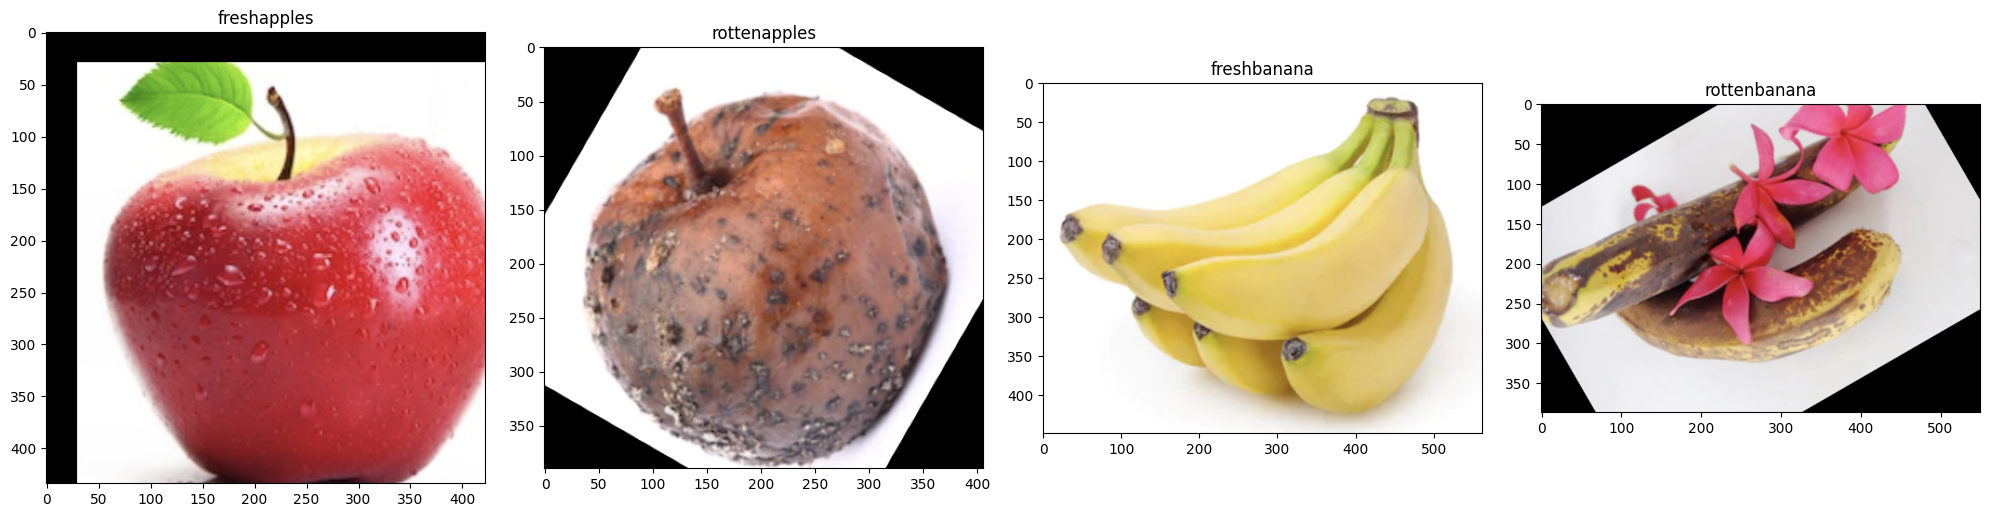

In [3]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

def visualize_sample_images(dataset_dir, categories):
    n = len(categories)
    fig, axs = plt.subplots(1, n, figsize=(20, 5))
    for i, category in enumerate(categories):
        folder = os.path.join(dataset_dir, category)
        image_file = os.listdir(folder)[0]
        img_path = os.path.join(folder, image_file)
        img = load_img(img_path)
        axs[i].imshow(img)
        axs[i].set_title(category)
    plt.tight_layout()
    plt.show()

dataset_base_dir = os.path.join(swoyam2609_fresh_and_stale_classification_path, 'dataset')
train_dir = os.path.join(dataset_base_dir, 'Train')
categories = ['freshapples', 'rottenapples', 'freshbanana', 'rottenbanana']  # Add more categories as needed
visualize_sample_images(train_dir, categories)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
img_height = 180
img_width = 180

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)  # Using 20% of the data for validation

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # Use 'categorical' if you have more than two classes
    subset='training')

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation')


Found 18901 images belonging to 18 classes.
Found 4718 images belonging to 18 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Use 'softmax' for more than two classes
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',  # Use 'categorical_crossentropy' for more than two classes
              metrics=['accuracy'])

epochs = 10
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 1814s 3s/step - accuracy: 0.1045 - loss: -253415955365888.0000 - val_accuracy: 0.1044 - val_loss: -1570728730165248.0000
Epoch 2/10
  1/590 ━━━━━━━━━━━━━━━━━━━━ 25:31 3s/step - accuracy: 0.0312 - loss: -1743469362020352.0000

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


590/590 ━━━━━━━━━━━━━━━━━━━━ 149s 249ms/step - accuracy: 0.0312 - loss: -1743469362020352.0000 - val_accuracy: 0.1044 - val_loss: -1588734306811904.0000
Epoch 3/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 1816s 3s/step - accuracy: 0.1046 - loss: -18380291068395520.0000 - val_accuracy: 0.1046 - val_loss: -52132355988520960.0000
Epoch 4/10
  1/590 ━━━━━━━━━━━━━━━━━━━━ 34:07 3s/step - accuracy: 0.0625 - loss: -76630815085166592.0000

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


590/590 ━━━━━━━━━━━━━━━━━━━━ 199s 333ms/step - accuracy: 0.0625 - loss: -76630815085166592.0000 - val_accuracy: 0.1044 - val_loss: -52358765189529600.0000
Epoch 5/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 1896s 3s/step - accuracy: 0.1045 - loss: -172394420983824384.0000 - val_accuracy: 0.1040 - val_loss: -338407345199513600.0000
Epoch 6/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 199s 333ms/step - accuracy: 0.1250 - loss: -264596476791881728.0000 - val_accuracy: 0.1048 - val_loss: -338153289294020608.0000
Epoch 7/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 1916s 3s/step - accuracy: 0.1046 - loss: -734108866932899840.0000 - val_accuracy: 0.1046 - val_loss: -1180013471115247616.0000
Epoch 8/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 157s 262ms/step - accuracy: 0.0625 - loss: -1217104671244550144.0000 - val_accuracy: 0.1046 - val_loss: -1185428978198904832.0000
Epoch 9/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 2002s 3s/step - accuracy: 0.1044 - loss: -2091262457375883264.0000 - val_accuracy: 0.1046 - val_loss: -2989676844405489664.0000
Epoch 

In [6]:
eval_result = model.evaluate(train_generator)
print(f"Training Loss: {eval_result[0]}, Training Accuracy: {eval_result[1]}")


591/591 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.1045 - loss: -3154003804978937856.0000
Training Loss: -3.154003804978938e+18, Training Accuracy: 0.10449182242155075


In [8]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

def classify_image(image_path, model):
    img = image.load_img(image_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Create a batch
    img_array /= 255.0

    predictions = model.predict(img_array)
    # Assuming binary classification where 0 is Fresh and 1 is Rotten
    if predictions[0] > 0.5:
        print("Rotten")
    else:
        print("Fresh")

# Example usage: Correcting the image_path
# We need to use the actual path where the dataset was downloaded
# and pick an existing image from one of the categories.

# Let's pick a 'rottenapples' image as an example.
rotten_apples_dir = os.path.join(train_dir, 'rottenapples')
if os.path.exists(rotten_apples_dir) and os.listdir(rotten_apples_dir):
    # Get the first image file from the 'rottenapples' directory
    sample_image_name = os.listdir(rotten_apples_dir)[0]
    image_path = os.path.join(rotten_apples_dir, sample_image_name)
    print(f"Using image for classification: {image_path}")
    classify_image(image_path, model)
else:
    print(f"Directory '{rotten_apples_dir}' not found or is empty. Cannot classify example image.")
    print("Please ensure 'rottenapples' directory exists in your training data.")

Using image for classification: /root/.cache/kagglehub/datasets/swoyam2609/fresh-and-stale-classification/versions/1/dataset/Train/rottenapples/rotated_by_60_Screen Shot 2018-06-07 at 2.38.49 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
Rotten
